In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import os
from tqdm import tqdm
import stackview
from skimage.filters import threshold_otsu
from scipy import ndimage
import yaml

In [4]:
# Load an image

In [5]:
im = tiff.imread('/Volumes/tungsten/scratch/ggiorget/nessim/microscopy_data/FRAP_Rad21_halo/20231124_FRAP_WAPL_AID_NIPBL_FKBP/20231124_FRAP_NIPBL_FKBP_Rad21_Halo_561_1_conf561Triple-LP-FRAP.ome.tf2')

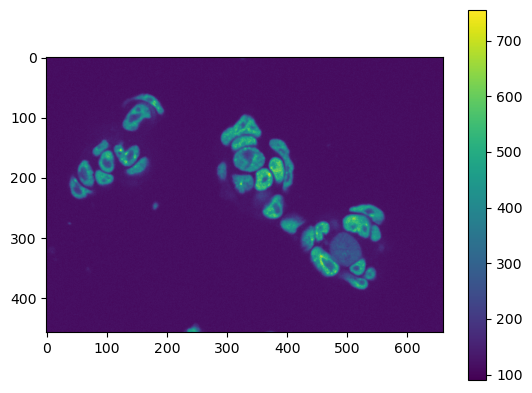

In [ ]:
plt.imshow(im[0,:], cmap='viridis')
plt.colorbar()
plt.show()

In [6]:

def compute_lab (im_roi):#labels = np.zeros_like(im_roi[0:82,...])
    labels_final = np.zeros_like(im_roi)

    for frame in tqdm(range(im_roi.shape[0])):
        labels = ndimage.binary_fill_holes(im_roi[frame,...] > threshold_otsu(im_roi[frame,...]))
        labs, num_features = ndimage.label(labels)
        #count pixels of each component and sort them by size, excluding the background
        vol_list = []
        label_unique = np.unique(labs)

        for labl in label_unique:
            if labl != 0:
                vol_list.append(np.count_nonzero(labs == labl))

        #create binary array of only the largest component
        # binary_mask = labs
        binary_mask = np.zeros(labs.shape)
        binary_mask = np.where(labs == vol_list.index(max(vol_list))+1, 1, 0)
        labels_final[frame,...] = binary_mask
    return labels_final

In [8]:
stackview.slice(im, colormap='gray', zoom_factor=1)

# Test nuclei segmentation

## 1st roi

In [38]:
im_s = im[0,:]

In [39]:
thresh = threshold_otsu(im_s)
binary = im_s > thresh

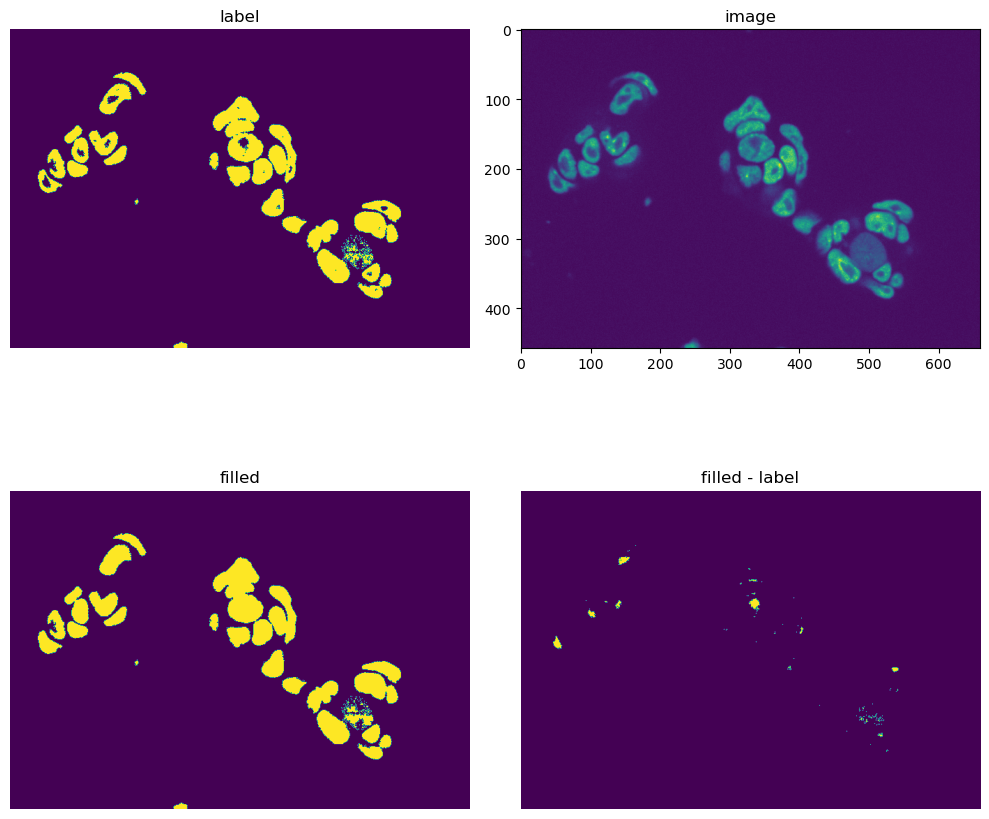

In [47]:
fig,ax = plt.subplots(2,2,figsize=(10,10))
ax = ax.ravel()

ax[0].imshow(binary, cmap='viridis')
ax[0].axis('off')
ax[0].set_title('label')
ax[1].imshow(im_s, cmap='viridis')
#ax[1].axis('off')
ax[1].set_title('image')

ax[2].imshow(ndimage.binary_fill_holes(binary).astype(int), cmap='viridis')
ax[2].axis('off')
ax[2].set_title('filled')

ax[3].imshow( ndimage.binary_fill_holes(binary).astype(int)- binary, cmap='viridis')
ax[3].axis('off')
ax[3].set_title('filled - label')

plt.tight_layout()

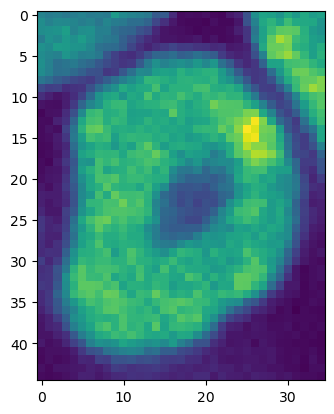

In [48]:
im_roi = im[:,180:225,345:380]

plt.imshow(im_roi[0,:], cmap='viridis')

In [49]:
thresh = threshold_otsu(im_roi[0,:])
binary = im_roi[0,...] > thresh

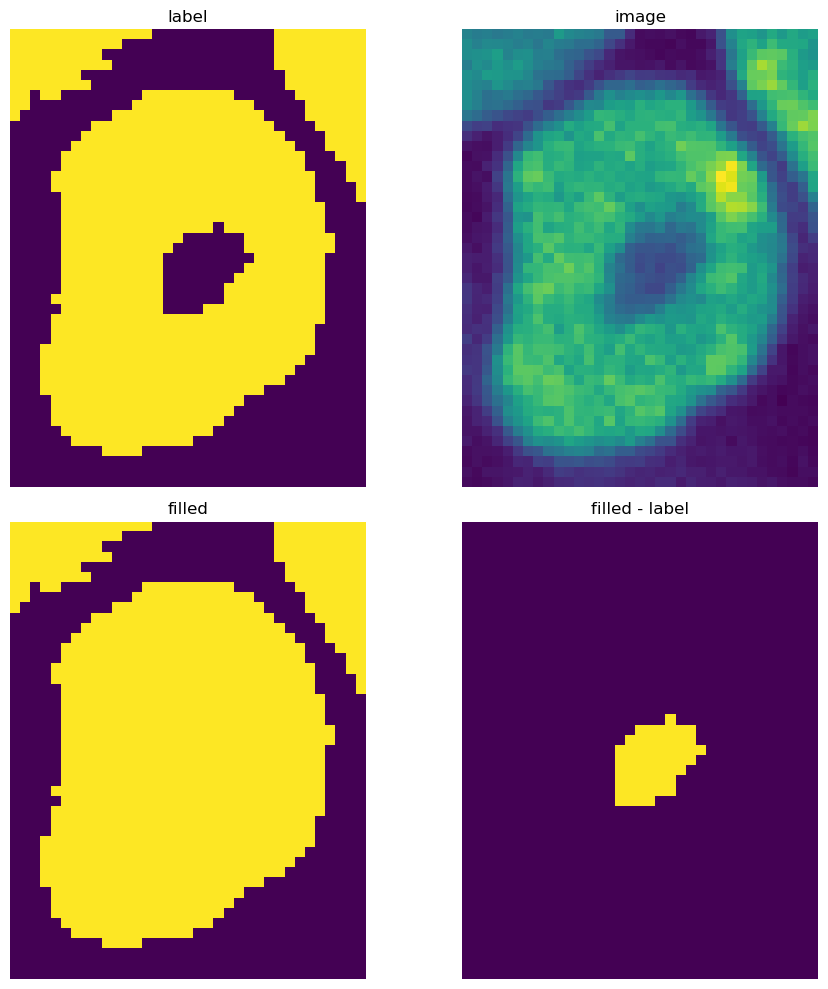

In [52]:
fig,ax = plt.subplots(2,2,figsize=(10,10))
ax = ax.ravel()

ax[0].imshow(binary, cmap='viridis')
ax[0].axis('off')
ax[0].set_title('label')
ax[1].imshow(im_roi[0,...], cmap='viridis')
ax[1].axis('off')
ax[1].set_title('image')

ax[2].imshow(ndimage.binary_fill_holes(binary).astype(int), cmap='viridis')
ax[2].axis('off')
ax[2].set_title('filled')

ax[3].imshow( ndimage.binary_fill_holes(binary).astype(int)- binary, cmap='viridis')
ax[3].axis('off')
ax[3].set_title('filled - label')

plt.tight_layout()

In [54]:
## test segmentation over time

In [58]:
stackview.slice(im_roi, colormap='gray', zoom_factor=10)

In [82]:
#labels = np.zeros_like(im_roi[0:82,...])
labels_final = np.zeros_like(im_roi)

for frame in tqdm(range(im_roi.shape[0])):
    labels = ndimage.binary_fill_holes(im_roi[frame,...] > threshold_otsu(im_roi[frame,...]))
    labs, num_features = ndimage.label(labels)
    #count pixels of each component and sort them by size, excluding the background
    vol_list = []
    label_unique = np.unique(labs)

    for labl in label_unique:
        if labl != 0:
            vol_list.append(np.count_nonzero(labs == labl))

    #create binary array of only the largest component
    binary_mask = np.zeros(labs.shape)
    binary_mask = np.where(labs == vol_list.index(max(vol_list))+1, 1, 0)
    labels_final[frame,...] = binary_mask

100%|██████████| 250/250 [00:00<00:00, 2517.75it/s]


In [83]:
stackview.slice(labels_final, colormap='gray', zoom_factor=10)

In [73]:
int_img = im_roi[0:82,...].copy()

In [74]:
int_im = int_img*(labels_final==1.)


In [79]:
intensities = np.zeros(82)
for frame in tqdm(range(82)):
    intensities[frame] = np.mean(int_im[frame,...])


100%|██████████| 82/82 [00:00<00:00, 40706.94it/s]


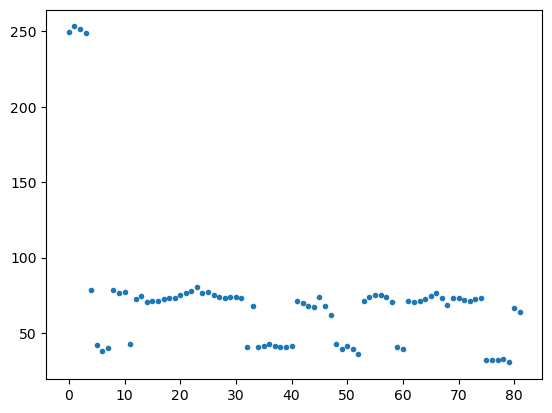

In [81]:
plt.scatter(range(82), intensities,marker='.')

## unfrapped region

This cell will be used to correct for photobleaching of the fluorophore and any change in global intensity

In [101]:
im_unfrap = im[:,152:195,87:132]

In [102]:
labels_final = compute_lab(im_unfrap)

100%|██████████| 250/250 [00:00<00:00, 5643.82it/s]


In [10]:
stackview.slice(labels_final, colormap='gray', zoom_factor=10)

In [103]:
int_im = im_unfrap*(labels_final==1.) #mask the image with the label

intensity_bleach = []
for frame in tqdm(range(np.shape(int_im)[0])):
    intensity_bleach.append(np.mean(int_im[frame,...][int_im[frame,...]>0])) #compute the mean intensity of the masked image without the background (0)

100%|██████████| 250/250 [00:00<00:00, 93281.38it/s]


In [78]:
stackview.slice(int_im, colormap='gray', zoom_factor=10)

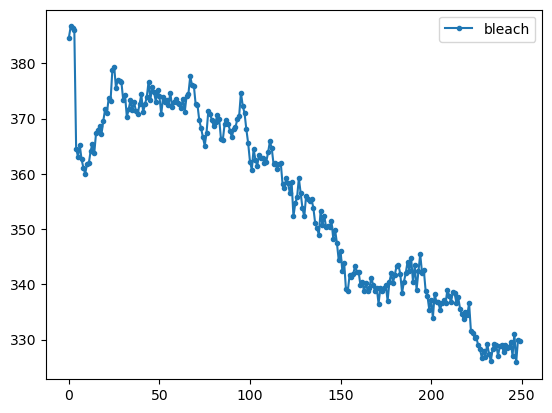

In [90]:
plt.plot(intensity_bleach,marker='.',label='bleach') # bleaching curve
plt.legend()
plt.show()

## 2nd ROI

In [4]:
stackview.slice(im[:,210:275,355:405], colormap='gray', zoom_factor=10)

In [13]:
im_r = im[:,210:275,355:405] 

labels_final = compute_lab(im_r)

100%|██████████| 250/250 [00:00<00:00, 4622.27it/s]


In [7]:
stackview.slice(labels_final, colormap='gray', zoom_factor=10)

I define the bleach and unbleach region naively using the frame before and after FRAP:
- The bleached region is the masking of the image before FRAP with the signal left in the next frame
- The unbleached region is the opposite 

In [97]:
bleached_region = labels_final[3,...] * (labels_final[4,...]==0.)

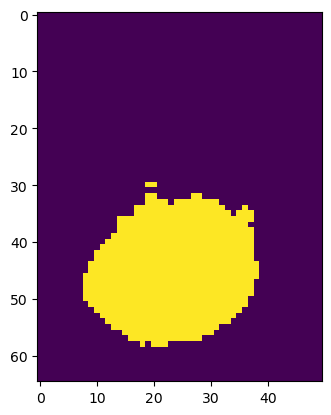

In [10]:
plt.imshow(bleached_region, cmap='viridis')

In [98]:
unbleached_region = labels_final[4,...] * (labels_final[0,...]==1.)

In [12]:
stackview.slice(labels_final*(bleached_region==0.), colormap='gray', zoom_factor=10)

I define the background as the mean intensity of the image without the cell (background coming from the microscope). It is more precisely the image masked with the labels ( $A\cup B - A\cap B$ )

In [99]:
background = im_r*(labels_final==0.)


In [105]:
stackview.slice(background, colormap='gray', zoom_factor=10)

In [100]:
int_im = im_r*(unbleached_region==1.)
int_im_b = im_r*(unbleached_region==0.)
background = im_r*(labels_final==0.)

intensities_un = np.zeros(np.shape(im_r)[0])
intensities_b = np.zeros(np.shape(im_r)[0])
int_background = np.zeros(np.shape(im_r)[0])

for frame in tqdm(range(np.shape(im_r)[0])):
    intensities_un[frame] = np.mean(int_im[frame,...][int_im[frame,...]>0])
    intensities_b[frame] = np.mean(int_im_b[frame,...][int_im_b[frame,...]>0])
    int_background[frame] = np.mean(background[frame,...][background[frame,...]>0])

100%|██████████| 250/250 [00:00<00:00, 32865.57it/s]


(-0.9, 80.0)

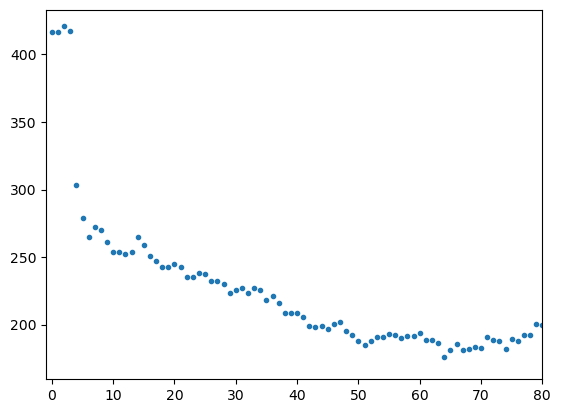

In [97]:
plt.scatter(range(np.shape(im_r)[0]), intensities_un,marker='.')
plt.xlim(-0.9,80)

(140.0, 160.0)

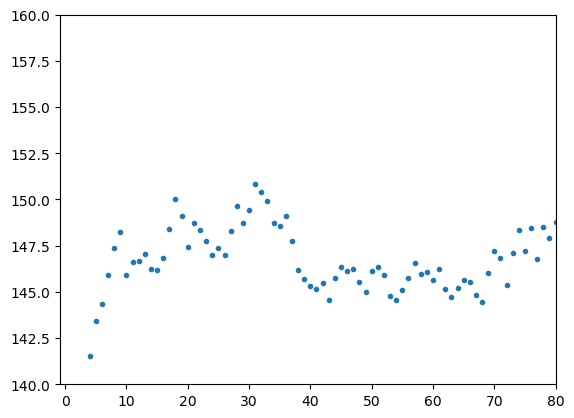

In [100]:
plt.scatter(range(np.shape(im_r)[0]), intensities_b,marker='.')
plt.xlim(-0.9,80)
plt.ylim(140,160)

In [107]:
iFRAP = (intensities_un-intensities_b)/(intensity_bleach- int_background) #compute the iFRAP curve as defined by Gabriele et al. science 2022

In [120]:
frame = [i*0.5 for i in range(len(iFRAP))]
frame

[0.0,
 0.5,
 1.0,
 1.5,
 2.0,
 2.5,
 3.0,
 3.5,
 4.0,
 4.5,
 5.0,
 5.5,
 6.0,
 6.5,
 7.0,
 7.5,
 8.0,
 8.5,
 9.0,
 9.5,
 10.0,
 10.5,
 11.0,
 11.5,
 12.0,
 12.5,
 13.0,
 13.5,
 14.0,
 14.5,
 15.0,
 15.5,
 16.0,
 16.5,
 17.0,
 17.5,
 18.0,
 18.5,
 19.0,
 19.5,
 20.0,
 20.5,
 21.0,
 21.5,
 22.0,
 22.5,
 23.0,
 23.5,
 24.0,
 24.5,
 25.0,
 25.5,
 26.0,
 26.5,
 27.0,
 27.5,
 28.0,
 28.5,
 29.0,
 29.5,
 30.0,
 30.5,
 31.0,
 31.5,
 32.0,
 32.5,
 33.0,
 33.5,
 34.0,
 34.5,
 35.0,
 35.5,
 36.0,
 36.5,
 37.0,
 37.5,
 38.0,
 38.5,
 39.0,
 39.5,
 40.0,
 40.5,
 41.0,
 41.5,
 42.0,
 42.5,
 43.0,
 43.5,
 44.0,
 44.5,
 45.0,
 45.5,
 46.0,
 46.5,
 47.0,
 47.5,
 48.0,
 48.5,
 49.0,
 49.5,
 50.0,
 50.5,
 51.0,
 51.5,
 52.0,
 52.5,
 53.0,
 53.5,
 54.0,
 54.5,
 55.0,
 55.5,
 56.0,
 56.5,
 57.0,
 57.5,
 58.0,
 58.5,
 59.0,
 59.5,
 60.0,
 60.5,
 61.0,
 61.5,
 62.0,
 62.5,
 63.0,
 63.5,
 64.0,
 64.5,
 65.0,
 65.5,
 66.0,
 66.5,
 67.0,
 67.5,
 68.0,
 68.5,
 69.0,
 69.5,
 70.0,
 70.5,
 71.0,
 71.5,
 72.0,
 72.5

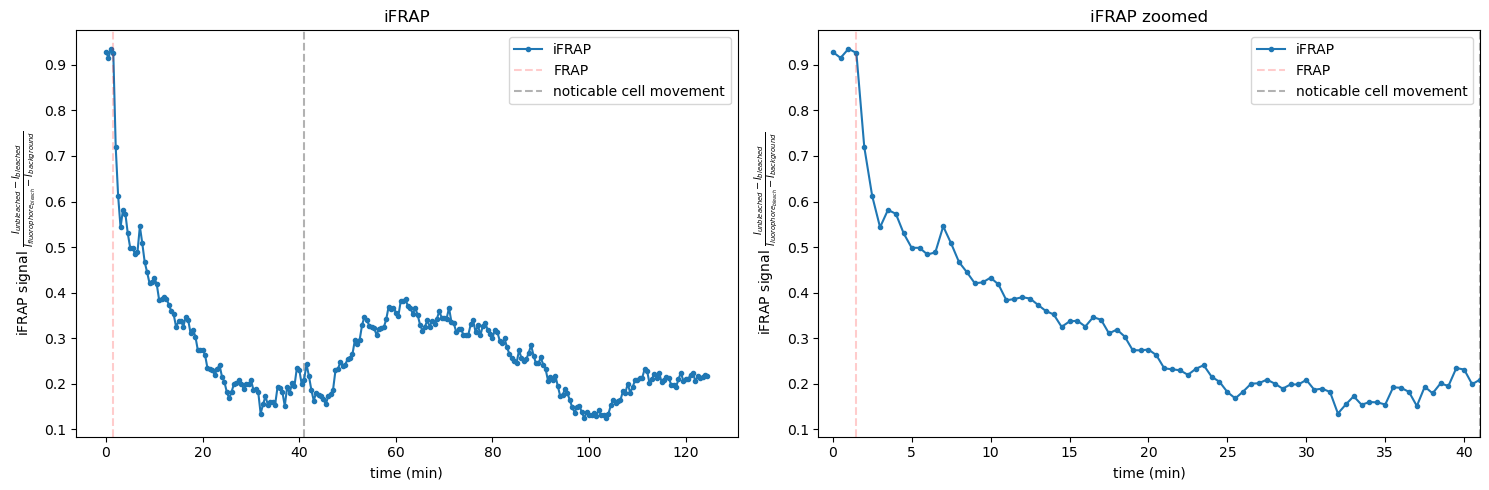

In [124]:
fig,ax = plt.subplots(1,2,figsize=(15,5))

for pl in ax:
    pl.plot(frame,iFRAP,marker='.',label='iFRAP')
    pl.axvline((3*0.5), color='r', linestyle='--',label='FRAP',alpha=0.2)
    pl.axvline((82*0.5), color='black', linestyle='--',label='noticable cell movement',zorder=0,alpha=0.3)

ax[0].set_title('iFRAP')
ax[1].set_title('iFRAP zoomed')
ax[0].set_xlabel('time (min)')
ax[1].set_xlabel('time (min)')
ax[0].set_ylabel(r'iFRAP signal $\frac{I_{unbleached}-I_{bleached}}{I_{fluorophore_{bleach}}-I_{background}}$')
ax[1].set_ylabel(r'iFRAP signal $\frac{I_{unbleached}-I_{bleached}}{I_{luorophore_{bleach}}-I_{background}}$')
ax[0].legend()
ax[1].legend()
ax[1].set_xlim(-0.9,(82*0.5))
plt.tight_layout()
plt.savefig('/tungstenfs/scratch/ggiorget/nessim/cohesin_residence_time/cohesin_residence_time/scratchpad/plots/iFRAP.png',dpi=300)
plt.show()

The problem with the curve is cell movement. The way I defined the ROI is static and thus doesn't account for cell motion. I need to find a way to actualize the ROI for cell motion

# Test image annotation with stackview

In [7]:
labels = np.zeros(im_r.shape).astype(np.uint8)

stackview.annotate(im_r, labels, colormap='gray', zoom_factor=10,continuous_update=False)

/tungstenfs/scratch/ggiorget/nessim/miniconda3/envs/cohesin_residence_time/lib/python3.9/site-packages/stackview/_annotate.py:81: UserWarning: Labels are not an image of type uint32 or uint64. Consider converting to this type for best performance.
  warnings.warn("Labels are not an image of type uint32 or uint64. Consider converting to this type for best performance.")


In [ ]:
np.unique(labels)

array([0, 1, 2], dtype=uint8)

# Test interactive plotting

In [7]:
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import time

In [12]:
a = [ ]
for i in range(52):
    if i % 25 == 0:
        plt.imshow(im_r[i,...], cmap='viridis')
        a.append(plt.ginput(1))
        plt.imshow(plt.disk(2))
    else:
        continue
plt.close()

In [14]:
from skimage.morphology import disk

In [20]:
plt.imshow(im_r[0,...], cmap='viridis')
plt.show()

ValueError: operands could not be broadcast together with shapes (65,50) (11,11) 

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

mean_list_bleached = []
mean_list_unbleached = []

frames = []
# Get the shape of your image
height, width = im_r[0,...].shape

counter = 1
plt.waitforbuttonpress()

for i in range(0,im_r.shape[0]):
    if counter % 25 == 0 or i in [0,1,2,3,5,249]:
        counter += 1

        # Display the image
        plt.subplot(1,2,1)
        plt.imshow(im_r[i,...], cmap='viridis')
        plt.title(f'Frame {i}')

        radius = 5
        radius_b = 7
        # Create a circle patch
        a = plt.ginput(2)
        x,y = a[0]
        x_b,y_b = a[1]

        circle = patches.Circle((x, y), radius, edgecolor='r', facecolor='none')
        circle_b = patches.Circle((x_b, y_b), radius, edgecolor='green', facecolor='none')
        # Get the current axes, and add the circle to them
        ax = plt.gca()

        circle_stored = ax.add_patch(circle)
        circle_stored_b = ax.add_patch(circle_b)

        circle_stored.remove()
        circle_stored_b.remove()
        
        # Create an array of indices
        y_indices, x_indices = np.ogrid[:height, :width]
        y_indices_b, x_indices_b = np.ogrid[:height, :width]

        # Create a binary mask where the pixels inside the circle are True
        mask = (x_indices - x)**2 + (y_indices - y)**2 <= radius**2
        maks_bck = (x_indices_b - x_b)**2 + (y_indices_b - y_b)**2 <= radius_b**2

        # Use the mask to index into your image and extract the pixel values
        pixels_in_circle = im_r[i,...][mask]
        pixels_in_bck = im_r[i,...][maks_bck]
        plt.subplot(1,2,2)
        plt.imshow(mask, cmap='viridis')
        plt.imshow(maks_bck, cmap='viridis',alpha=0.5)
        plt.title(f'Mean intensity in this patch {np.mean(pixels_in_circle):.2f}, \n background {np.mean(pixels_in_bck):.2f}')

        mean_list_unbleached.append(np.mean(pixels_in_circle))
        mean_list_bleached.append(np.mean(pixels_in_bck))
        frames.append(i)
    else:
        counter += 1
        continue
    
if plt.waitforbuttonpress():
    plt.close()


: 

# Interpolation

In [208]:
import numpy as np
from scipy.interpolate import interp1d

In [216]:
# Original x values
x_values = np.array([0,1,2,3,5, 24, 49, 74, 99, 124, 149, 174, 199, 224, 249])

# Create interpolation function
f_unbleach = interp1d(x_values, mean_list_unbleached, kind='linear')
f_bleach = interp1d(x_values, mean_list_bleached, kind='linear')

# New x values for interpolation
x_new = np.arange(0, 250)

# Interpolate the data at new x values
interpolated_values_unbleached = f_unbleach(x_new)
interpolated_values_bleached = f_bleach(x_new)

iFRAP = (intensities_unbleached-intensities_bleached)/(intensity_bleach- int_background) #compute the iFRAP curve as defined by Gabriele et al. science 2022

In [217]:
iFRAP = (interpolated_values_unbleached-interpolated_values_bleached)/(intensity_bleach - int_background) #compute the iFRAP curve as defined by Gabriele et al. science 2022

In [218]:
frames_m = [x*0.5 for x in range(len(iFRAP))]  


In [226]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(interpolated_values_unbleached[5:],marker='.',label='mean intensity unbleached')
plt.plot(interpolated_values_bleached[5:],marker='.',label='mean intensity bleached')
plt.scatter(frames[5:],mean_list_unbleached[5:],marker='o',label='points unbleached')
plt.scatter(frames[5:],mean_list_bleached[5:],marker='o',label='points bleached')
plt.plot(intensity_bleach[5:],marker='.',label='bleach of fluorophore')
plt.plot(int_background[5:],marker='.',label='background')

plt.legend()
plt.subplot(1,2,2)
plt.plot(frames_m[5:],iFRAP[5:],marker='.',label='iFRAP')
plt.legend()

plt.show()


: 

In [182]:
plt.plot(frames_m,iFRAP,marker='.',label='iFRAP')
plt.axvline((3*0.5), color='r', linestyle='--',label='FRAP',alpha=0.2)
plt.axvline((82*0.5), color='black', linestyle='--',label='noticable cell movement',zorder=0,alpha=0.3)
plt.legend()
plt.show()


In [9]:
plt.figure()
plt.xlim(0, 1)
plt.ylim(0, 1)


plt.waitforbuttonpress()

while True:
    pts = []
    while len(pts) < 3:
        pts = np.asarray(plt.ginput(3, timeout=-1))
        if len(pts) < 3:
            time.sleep(1)  # Wait a second

    ph = plt.fill(pts[:, 0], pts[:, 1], 'r', lw=2)


    if plt.waitforbuttonpress():
        break

    # Get rid of fill
    for p in ph:
        p.remove()


In [25]:
plt.waitforbuttonpress()
plt.imshow(im[0,...],cmap='viridis')
coords = plt.ginput(1)

if plt.waitforbuttonpress():
    plt.close()


print('You entered %s' % coords)

You entered [(361.43548387096774, 204.8467741935483)]


In [26]:
c = [int(x) for x in coords[0]]

In [29]:
def zoomed_image(im, center, size):
    # Calculate the top left and bottom right coordinates of the square
    top_left = (center[1] - size // 2, center[0] - size // 2)
    bottom_right = (center[1] + size // 2, center[0] + size // 2)

    # Slice the image array to create the zoomed image
    zoomed_im = im[:, top_left[0]:bottom_right[0], top_left[1]:bottom_right[1]]

    return zoomed_im

# Use the function
center = c # Replace with the actual coordinates
size = 100  # Replace with the actual size


zoomed_im = zoomed_image(im, center, size)

In [30]:
plt.imshow(zoomed_im[0,...], cmap='viridis')
plt.show()

# parse the yaml file

In [10]:
with open('test_yaml.yml', 'r') as file:
    params = yaml.safe_load(file)

In [11]:
params

{'name_of_experiment': 'example',
 'FRAP_frame': 4,
 'im_path': '/Volumes/tungsten/scratch/ggiorget/nessim/microscopy_data/FRAP_Rad21_halo/20231124_FRAP_WAPL_AID_NIPBL_FKBP/20231124_FRAP_NIPBL_FKBP_Rad21_Halo_561_1_conf561Triple-LP-FRAP.ome.tf2',
 'size_of_bbox_zoom': 100,
 'frame_actualization': 25,
 'frame_pre_bleach': [0, 1, 2, 3, 5, 249],
 'radius_unbleach_spot': 5,
 'radius_bleach_spot': 7,
 'interpolation_values': [0,
  1,
  2,
  3,
  5,
  24,
  49,
  74,
  99,
  124,
  149,
  174,
  199,
  224,
  249],
 'save_path': '/Users/louaness/Documents/cohesin_residence_time/cohesin_residence_time/runs/example/'}

In [ ]:
im = tiff.imread(params['im_path'])

plt.waitforbuttonpress()
fig,ax = plt.subplots(1,2,figsize=(15,5))
ax[0].imshow(im[0,...],cmap='viridis')
ax[1].imshow(im[params['FRAP_frame'],...],cmap='viridis')
ax[0].set_title('pre-FRAP image')
ax[1].set_title('FRAP image')

if plt.waitforbuttonpress():
    plt.close()

plt.waitforbuttonpress()
number = 1# input('How many cells (ROIs) do you want to analyze?')

fig,ax = plt.subplots(1,2,figsize=(15,5))
ax[0].imshow(im[0,...],cmap='viridis')
ax[1].imshow(im[params['FRAP_frame'],...],cmap='viridis')
ax[0].set_title('pre-FRAP image')
ax[1].set_title('FRAP image')


coords = plt.ginput(int(number))

if plt.waitforbuttonpress():
    plt.close()


print('You entered %s' % coords)
im_unfrap = im[:,152:195,87:132]
labels_final = compute_lab(im_unfrap)

int_im = im_unfrap*(labels_final==1.) #mask the image with the label

intensity_bleach = []
for frame in tqdm(range(np.shape(int_im)[0])):
    intensity_bleach.append(np.mean(int_im[frame,...][int_im[frame,...]>0])) #compute the mean intensity of the masked image without the background (0)

ifrap = []
for coord in coords:
    c = [int(x) for x in list(coord)]
    # Use the function
    center = c # Replace with the actual coordinates
    size = params['size_of_bbox_zoom']  # Replace with the actual size


    zoomed_im = zoomed_image(im, center, size)

    im_r = zoomed_im

    labels_final = compute_lab(im_r)

    background = im_r*(labels_final==0.)

    int_background = np.zeros(np.shape(im_r)[0])

    for frame in tqdm(range(np.shape(im_r)[0])):
        int_background[frame] = np.mean(background[frame,...][background[frame,...]>0])

    mean_list_bleached = []
    mean_list_unbleached = []

    frames = []
    # Get the shape of your image
    height, width = im_r[0,...].shape

    counter = 1
    plt.waitforbuttonpress()

    print('Click on the center of the unbleached spot, then on the bleached spot')
    print('Press any key to end the selection')

    for i in range(0,im_r.shape[0]):
        if counter % params['frame_actualization'] == 0 or i in params['frame_pre_bleach']:
            counter += 1

            # Display the image
            plt.subplot(1,2,1)
            plt.imshow(im_r[i,...], cmap='viridis')
            plt.title(f'Frame {i}')

            radius = params['radius_unbleach_spot']
            radius_b = params['radius_bleach_spot']
            # Create a circle patch
            a = plt.ginput(2)
            x,y = a[0]
            x_b,y_b = a[1]

            circle = patches.Circle((x, y), radius, edgecolor='r', facecolor='none')
            circle_b = patches.Circle((x_b, y_b), radius, edgecolor='green', facecolor='none')
            # Get the current axes, and add the circle to them
            ax = plt.gca()

            circle_stored = ax.add_patch(circle)
            circle_stored_b = ax.add_patch(circle_b)

            circle_stored.remove()
            circle_stored_b.remove()
            
            # Create an array of indices
            y_indices, x_indices = np.ogrid[:height, :width]
            y_indices_b, x_indices_b = np.ogrid[:height, :width]

            # Create a binary mask where the pixels inside the circle are True
            mask = (x_indices - x)**2 + (y_indices - y)**2 <= radius**2
            maks_bck = (x_indices_b - x_b)**2 + (y_indices_b - y_b)**2 <= radius_b**2

            # Use the mask to index into your image and extract the pixel values
            pixels_in_circle = im_r[i,...][mask]
            pixels_in_bck = im_r[i,...][maks_bck]
            plt.subplot(1,2,2)
            plt.imshow(mask, cmap='viridis')
            plt.imshow(maks_bck, cmap='viridis',alpha=0.5)
            plt.title(f'Mean intensity in this patch {np.mean(pixels_in_circle):.2f}, \n background {np.mean(pixels_in_bck):.2f}')

            mean_list_unbleached.append(np.mean(pixels_in_circle))
            mean_list_bleached.append(np.mean(pixels_in_bck))
            frames.append(i)
        else:
            counter += 1
            continue

    if plt.waitforbuttonpress():
        plt.close()


    # Original x values
    x_values = np.array(params['interpolation_values'])

    # Create interpolation function
    f_unbleach = interp1d(x_values, mean_list_unbleached, kind='linear')
    f_bleach = interp1d(x_values, mean_list_bleached, kind='linear')

    # New x values for interpolation
    x_new = np.arange(0, 250)

    # Interpolate the data at new x values
    interpolated_values_unbleached = f_unbleach(x_new)
    interpolated_values_bleached = f_bleach(x_new)

    iFRAP = (interpolated_values_unbleached-interpolated_values_bleached)/(intensity_bleach - int_background) #compute the iFRAP curve as defined by Gabriele et al. science 2022

    ifrap.append(iFRAP)
    frames_m = [x*0.5 for x in range(len(iFRAP))]  

    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plt.plot(interpolated_values_unbleached[5:],marker='.',label='mean intensity unbleached')
    plt.plot(interpolated_values_bleached[5:],marker='.',label='mean intensity bleached')
    plt.scatter(frames[5:],mean_list_unbleached[5:],marker='o',label='points unbleached')
    plt.scatter(frames[5:],mean_list_bleached[5:],marker='o',label='points bleached')
    plt.plot(intensity_bleach[5:],marker='.',label='bleach of fluorophore')
    plt.plot(int_background[5:],marker='.',label='background')

    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(frames_m[5:],iFRAP[5:],marker='.',label='iFRAP')
    plt.legend()
    plt.show()

np.save(f'{params['save_path']}/{params['name_of_experiment']}.npy',ifrap)